In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

pd.set_option("display.max_columns", None)

In [3]:
file_path = "../data/processed/ml_ready_demand_2025_01.parquet"

df = pd.read_parquet(file_path)

print("Shape:", df.shape)
print("\nDate range:")
print(df["datetime"].min(), "to", df["datetime"].max())

print("\nMissing values:")
print(df.isna().sum())

df.head()

Shape: (151488, 13)

Date range:
2025-01-08 00:00:00 to 2025-01-31 23:00:00

Missing values:
datetime           0
hour               0
day_of_week_num    0
day_of_month       0
is_weekend         0
PULocationID       0
lag_1              0
lag_2              0
lag_24             0
lag_168            0
rolling_mean_3     0
rolling_mean_24    0
demand             0
dtype: int64


,datetime,hour,day_of_week_num,day_of_month,is_weekend,PULocationID,lag_1,lag_2,lag_24,lag_168,rolling_mean_3,rolling_mean_24,demand
0,2025-01-08 00:00:00,0,2,8,False,1,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2025-01-08 01:00:00,1,2,8,False,1,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2025-01-08 02:00:00,2,2,8,False,1,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2025-01-08 03:00:00,3,2,8,False,1,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2025-01-08 04:00:00,4,2,8,False,1,0.0,0.0,0.0,0.0,0.0,0.0,0


In [4]:
train = df[
    df["datetime"] < "2025-01-25"
].copy()

validation = df[
    (df["datetime"] >= "2025-01-25") &
    (df["datetime"] < "2025-01-28")
].copy()

test = df[
    df["datetime"] >= "2025-01-28"
].copy()

print("Training rows:", len(train))
print("Validation rows:", len(validation))
print("Test rows:", len(test))

print("\nTraining:")
print(train["datetime"].min(), "to", train["datetime"].max())

print("\nValidation:")
print(validation["datetime"].min(), "to", validation["datetime"].max())

print("\nTest:")
print(test["datetime"].min(), "to", test["datetime"].max())

Training rows: 107304
Validation rows: 18936
Test rows: 25248

Training:
2025-01-08 00:00:00 to 2025-01-24 23:00:00

Validation:
2025-01-25 00:00:00 to 2025-01-27 23:00:00

Test:
2025-01-28 00:00:00 to 2025-01-31 23:00:00


In [5]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


y_val = validation["demand"]

baseline_results = []

for name, column in [
    ("Previous Hour", "lag_1"),
    ("Previous Day", "lag_24"),
    ("Previous Week", "lag_168")
]:
    mae, rmse = evaluate_model(
        y_val,
        validation[column]
    )

    baseline_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse
    })

baseline_results = pd.DataFrame(baseline_results)

baseline_results

,Model,MAE,RMSE
0,Previous Hour,20.081221,35.604495
1,Previous Day,37.682985,75.773617
2,Previous Week,19.842153,40.374994


Train Linear Regression

In [6]:
features = [
    "hour",
    "day_of_week_num",
    "day_of_month",
    "is_weekend",
    "PULocationID",
    "lag_1",
    "lag_2",
    "lag_24",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_24"
]

X_train = train[features]
y_train = train["demand"]

X_val = validation[features]
y_val = validation["demand"]

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (107304, 11)
X_val shape: (18936, 11)


In [7]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

raw_linear_pred = linear_model.predict(X_val)

In [8]:
print("Negative predictions:", (raw_linear_pred < 0).sum())

print(
    f"Prediction range: {raw_linear_pred.min():.2f} "
    f"to {raw_linear_pred.max():.2f}"
)

Negative predictions: 1607
Prediction range: -68.52 to 1217.04


In [9]:
linear_pred = np.maximum(raw_linear_pred, 0)

In [10]:
linear_mae, linear_rmse = evaluate_model(
    y_val,
    linear_pred
)

print("LINEAR REGRESSION")
print(f"MAE:  {linear_mae:.2f}")
print(f"RMSE: {linear_rmse:.2f}")

LINEAR REGRESSION
MAE:  17.30
RMSE: 32.09


In [11]:
comparison = baseline_results.copy()

comparison.loc[len(comparison)] = [
    "Linear Regression",
    linear_mae,
    linear_rmse
]

comparison = comparison.sort_values("MAE").reset_index(drop=True)

comparison

,Model,MAE,RMSE
0,Linear Regression,17.296208,32.091096
1,Previous Week,19.842153,40.374994
2,Previous Hour,20.081221,35.604495
3,Previous Day,37.682985,75.773617


Random Forest Regressor

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

In [13]:
rf_mae, rf_rmse = evaluate_model(
    y_val,
    rf_pred
)

print("RANDOM FOREST")
print(f"MAE:  {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")

print(
    f"Prediction range: {rf_pred.min():.2f} "
    f"to {rf_pred.max():.2f}"
)

RANDOM FOREST
MAE:  16.77
RMSE: 32.05
Prediction range: 0.00 to 1198.28


In [14]:
comparison.loc[len(comparison)] = [
    "Random Forest",
    rf_mae,
    rf_rmse
]

comparison = (
    comparison
    .sort_values("MAE")
    .reset_index(drop=True)
)

comparison

,Model,MAE,RMSE
0,Random Forest,16.772401,32.045612
1,Linear Regression,17.296208,32.091096
2,Previous Week,19.842153,40.374994
3,Previous Hour,20.081221,35.604495
4,Previous Day,37.682985,75.773617


In [15]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,feature,importance
0,lag_1,0.751804
1,lag_168,0.178630
2,lag_24,0.046680
3,day_of_month,0.005824
4,hour,0.004063
5,rolling_mean_24,0.003976
6,lag_2,0.002762
7,rolling_mean_3,0.002656
8,PULocationID,0.001783
9,day_of_week_num,0.001602


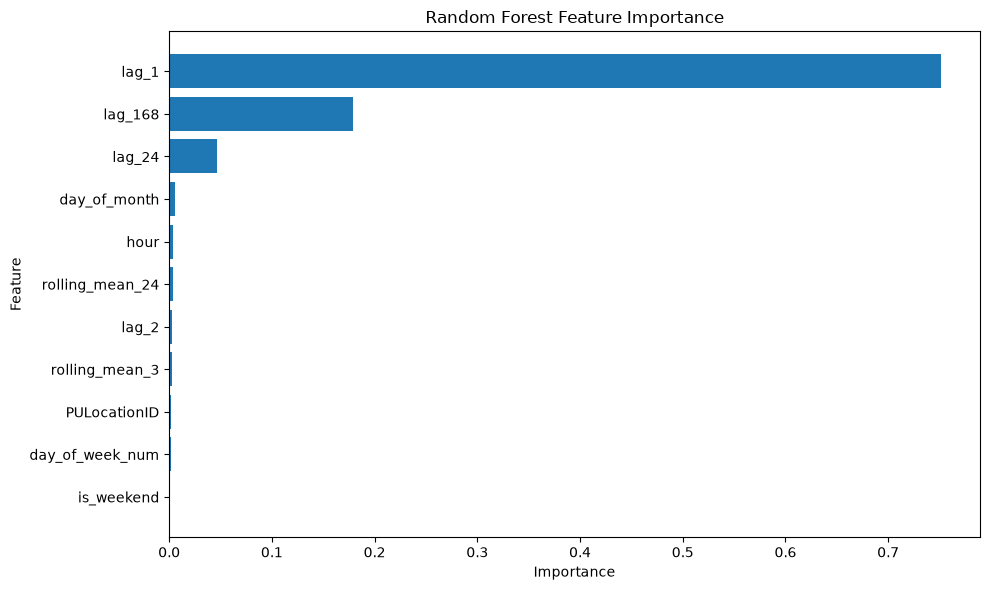

In [16]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [17]:
val_results = validation[
    [
        "datetime",
        "PULocationID",
        "hour",
        "day_of_week_num",
        "demand"
    ]
].copy()

val_results["predicted_demand"] = rf_pred

val_results["absolute_error"] = np.abs(
    val_results["demand"] -
    val_results["predicted_demand"]
)

val_results["error"] = (
    val_results["predicted_demand"] -
    val_results["demand"]
)

val_results.head()

,datetime,PULocationID,hour,day_of_week_num,demand,predicted_demand,absolute_error,error
408,2025-01-25 00:00:00,1,0,5,0,0.134549,0.134549,0.134549
409,2025-01-25 01:00:00,1,1,5,0,0.003981,0.003981,0.003981
410,2025-01-25 02:00:00,1,2,5,0,0.002333,0.002333,0.002333
411,2025-01-25 03:00:00,1,3,5,0,0.002333,0.002333,0.002333
412,2025-01-25 04:00:00,1,4,5,0,0.002333,0.002333,0.002333


In [18]:
print("Median absolute error:",
      round(val_results["absolute_error"].median(), 2))

print("90th percentile absolute error:",
      round(val_results["absolute_error"].quantile(0.90), 2))

print("95th percentile absolute error:",
      round(val_results["absolute_error"].quantile(0.95), 2))

print("99th percentile absolute error:",
      round(val_results["absolute_error"].quantile(0.99), 2))

Median absolute error: 8.16
90th percentile absolute error: 40.61
95th percentile absolute error: 62.85
99th percentile absolute error: 126.49


In [19]:
val_results.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,datetime,PULocationID,hour,day_of_week_num,demand,predicted_demand,absolute_error,error
79367,2025-01-26 23:00:00,138,23,6,1188,593.707877,594.292123,-594.292123
79320,2025-01-25 00:00:00,138,0,5,63,569.726791,506.726791,506.726791
79368,2025-01-27 00:00:00,138,0,0,437,942.938024,505.938024,505.938024
79365,2025-01-26 21:00:00,138,21,6,1060,575.171349,484.828651,-484.828651
92636,2025-01-27 20:00:00,161,20,0,938,493.009482,444.990518,-444.990518
79361,2025-01-26 17:00:00,138,17,6,1034,598.075165,435.924835,-435.924835
79359,2025-01-26 15:00:00,138,15,6,983,593.085455,389.914545,-389.914545
79364,2025-01-26 20:00:00,138,20,6,934,544.923310,389.076690,-389.076690
79369,2025-01-27 01:00:00,138,1,0,72,446.235304,374.235304,374.235304
93212,2025-01-27 20:00:00,162,20,0,625,250.951632,374.048368,-374.048368


Gradient Boosting

In [20]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.08,
    max_iter=300,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

hgb_model.fit(X_train, y_train)

hgb_pred = hgb_model.predict(X_val)

# Demand cannot be negative
hgb_pred = np.maximum(hgb_pred, 0)

hgb_mae, hgb_rmse = evaluate_model(
    y_val,
    hgb_pred
)

print("HISTOGRAM GRADIENT BOOSTING")
print(f"MAE:  {hgb_mae:.2f}")
print(f"RMSE: {hgb_rmse:.2f}")
print(
    f"Prediction range: {hgb_pred.min():.2f} "
    f"to {hgb_pred.max():.2f}"
)

HISTOGRAM GRADIENT BOOSTING
MAE:  16.56
RMSE: 31.35
Prediction range: 0.00 to 1083.65


In [21]:
comparison.loc[len(comparison)] = [
    "Hist Gradient Boosting",
    hgb_mae,
    hgb_rmse
]

comparison = (
    comparison
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("MAE")
    .reset_index(drop=True)
)

comparison

,Model,MAE,RMSE
0,Hist Gradient Boosting,16.555642,31.351028
1,Random Forest,16.772401,32.045612
2,Linear Regression,17.296208,32.091096
3,Previous Week,19.842153,40.374994
4,Previous Hour,20.081221,35.604495
5,Previous Day,37.682985,75.773617


Tune Hist Gradient Boosting

In [22]:
hgb_configs = [
    {
        "name": "HGB_A",
        "learning_rate": 0.05,
        "max_iter": 400,
        "max_leaf_nodes": 31,
        "l2_regularization": 1.0
    },
    {
        "name": "HGB_B",
        "learning_rate": 0.08,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "l2_regularization": 1.0
    },
    {
        "name": "HGB_C",
        "learning_rate": 0.05,
        "max_iter": 400,
        "max_leaf_nodes": 63,
        "l2_regularization": 1.0
    },
    {
        "name": "HGB_D",
        "learning_rate": 0.08,
        "max_iter": 300,
        "max_leaf_nodes": 63,
        "l2_regularization": 2.0
    }
]

tuning_results = []

for config in hgb_configs:

    model = HistGradientBoostingRegressor(
        learning_rate=config["learning_rate"],
        max_iter=config["max_iter"],
        max_leaf_nodes=config["max_leaf_nodes"],
        l2_regularization=config["l2_regularization"],
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)
    pred = np.maximum(pred, 0)

    mae, rmse = evaluate_model(y_val, pred)

    tuning_results.append({
        "Model": config["name"],
        "Learning Rate": config["learning_rate"],
        "Iterations": config["max_iter"],
        "Max Leaf Nodes": config["max_leaf_nodes"],
        "L2": config["l2_regularization"],
        "MAE": mae,
        "RMSE": rmse
    })

tuning_results = pd.DataFrame(tuning_results)

tuning_results.sort_values(
    ["MAE", "RMSE"]
).reset_index(drop=True)

,Model,Learning Rate,Iterations,Max Leaf Nodes,L2,MAE,RMSE
0,HGB_C,0.05,400,63,1.0,16.401461,31.357222
1,HGB_D,0.08,300,63,2.0,16.461426,31.391656
2,HGB_B,0.08,300,31,1.0,16.555642,31.351028
3,HGB_A,0.05,400,31,1.0,16.709543,31.486590


In [23]:
train_val = pd.concat(
    [train, validation],
    ignore_index=True
)

print("Final training rows:", len(train_val))
print(
    "Final training range:",
    train_val["datetime"].min(),
    "to",
    train_val["datetime"].max()
)

print("\nTest rows:", len(test))
print(
    "Test range:",
    test["datetime"].min(),
    "to",
    test["datetime"].max()
)

Final training rows: 126240
Final training range: 2025-01-08 00:00:00 to 2025-01-27 23:00:00

Test rows: 25248
Test range: 2025-01-28 00:00:00 to 2025-01-31 23:00:00


In [24]:
X_train_final = train_val[features]
y_train_final = train_val["demand"]

X_test = test[features]
y_test = test["demand"]

In [25]:
final_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_leaf_nodes=63,
    l2_regularization=1.0,
    random_state=42
)

final_model.fit(
    X_train_final,
    y_train_final
)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",400
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",63
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",1.0
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


In [26]:
test_pred = final_model.predict(X_test)

test_pred = np.maximum(
    test_pred,
    0
)

In [27]:
final_mae, final_rmse = evaluate_model(
    y_test,
    test_pred
)

print("FINAL TEST PERFORMANCE")
print("----------------------")
print(f"MAE:  {final_mae:.2f}")
print(f"RMSE: {final_rmse:.2f}")

print(
    f"Prediction range: "
    f"{test_pred.min():.2f} to {test_pred.max():.2f}"
)

FINAL TEST PERFORMANCE
----------------------
MAE:  12.76
RMSE: 22.16
Prediction range: 0.00 to 1045.13


In [28]:
from sklearn.metrics import r2_score

final_r2 = r2_score(
    y_test,
    test_pred
)

print(f"R²: {final_r2:.4f}")

R²: 0.9638


In [29]:
test_results = test[
    ["datetime", "PULocationID", "demand"]
].copy()

test_results["predicted_demand"] = test_pred

hourly_test = (
    test_results
    .groupby("datetime", as_index=False)
    .agg(
        actual_demand=("demand", "sum"),
        predicted_demand=("predicted_demand", "sum")
    )
)

hourly_test.head()

,datetime,actual_demand,predicted_demand
0,2025-01-28 00:00:00,12174,13801.336682
1,2025-01-28 01:00:00,6916,7407.443097
2,2025-01-28 02:00:00,4481,4294.492311
3,2025-01-28 03:00:00,4197,4196.520272
4,2025-01-28 04:00:00,6456,7092.712058


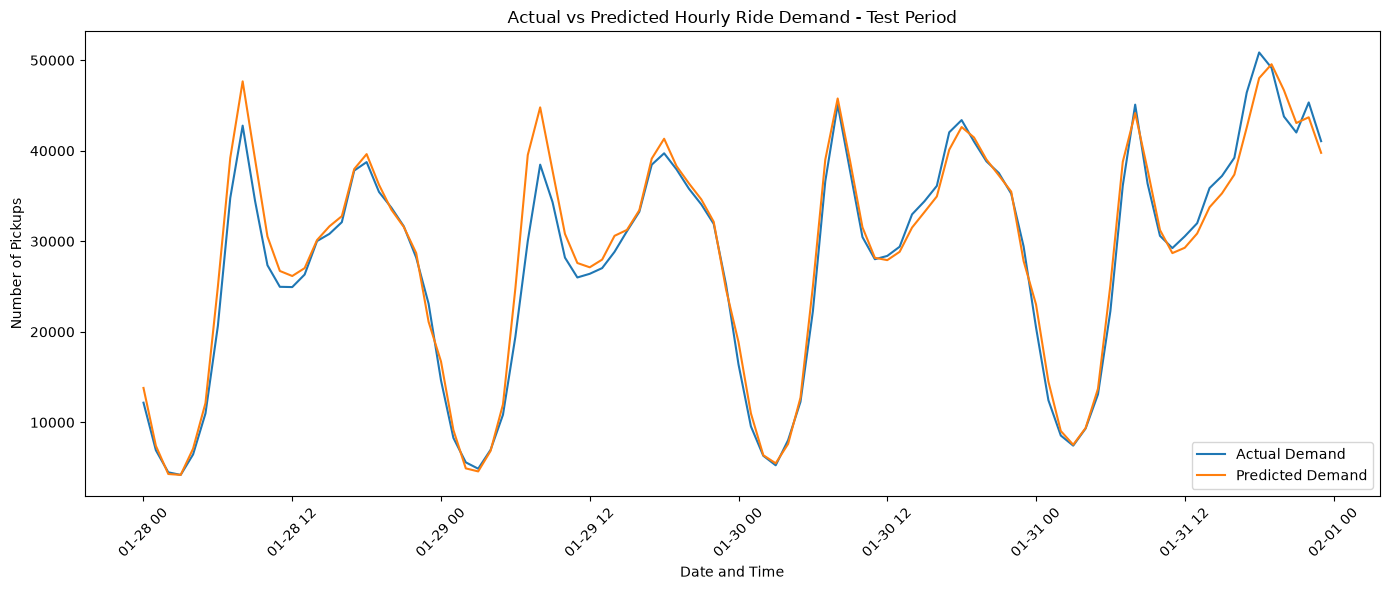

In [30]:
plt.figure(figsize=(14, 6))

plt.plot(
    hourly_test["datetime"],
    hourly_test["actual_demand"],
    label="Actual Demand"
)

plt.plot(
    hourly_test["datetime"],
    hourly_test["predicted_demand"],
    label="Predicted Demand"
)

plt.title("Actual vs Predicted Hourly Ride Demand - Test Period")
plt.xlabel("Date and Time")
plt.ylabel("Number of Pickups")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

final error distribution

In [31]:
test_results["absolute_error"] = np.abs(
    test_results["demand"] -
    test_results["predicted_demand"]
)

print("TEST ERROR DISTRIBUTION")
print("-----------------------")

print(
    "Median absolute error:",
    round(test_results["absolute_error"].median(), 2)
)

print(
    "90th percentile:",
    round(test_results["absolute_error"].quantile(0.90), 2)
)

print(
    "95th percentile:",
    round(test_results["absolute_error"].quantile(0.95), 2)
)

print(
    "99th percentile:",
    round(test_results["absolute_error"].quantile(0.99), 2)
)

TEST ERROR DISTRIBUTION
-----------------------
Median absolute error: 6.91
90th percentile: 30.97
95th percentile: 43.89
99th percentile: 80.43


In [32]:
import joblib

model_path = "../models/final_hgb_demand_model.joblib"

joblib.dump(final_model, model_path)

print("Model saved to:", model_path)

Model saved to: ../models/final_hgb_demand_model.joblib


In [33]:
feature_path = "../models/model_features.joblib"

joblib.dump(features, feature_path)

print("Features saved to:", feature_path)

Features saved to: ../models/model_features.joblib


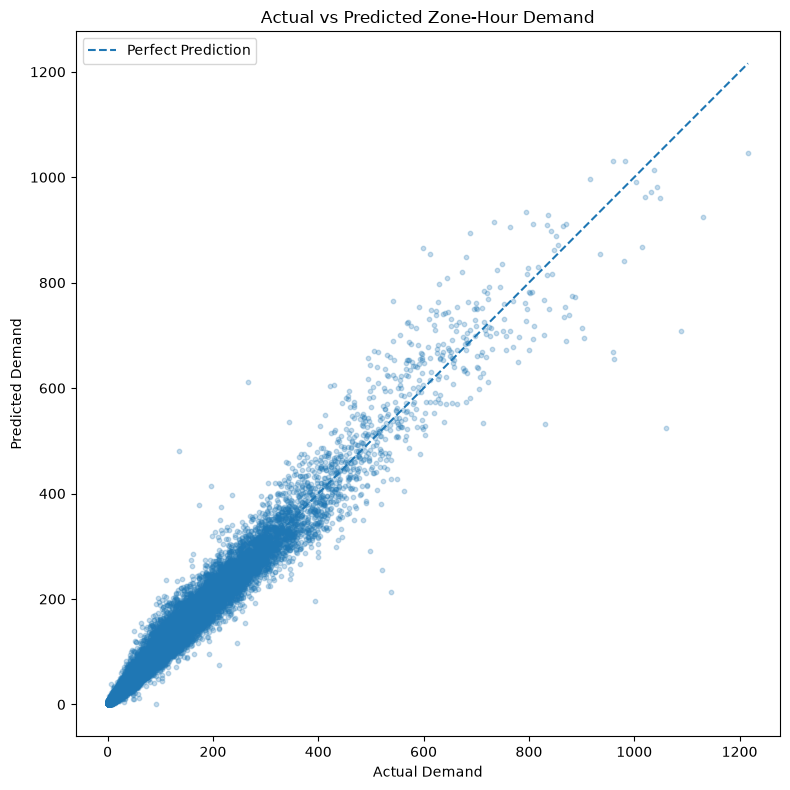

In [34]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    test_pred,
    alpha=0.25,
    s=10
)

max_value = max(y_test.max(), test_pred.max())

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Zone-Hour Demand")

plt.legend()
plt.tight_layout()
plt.show()

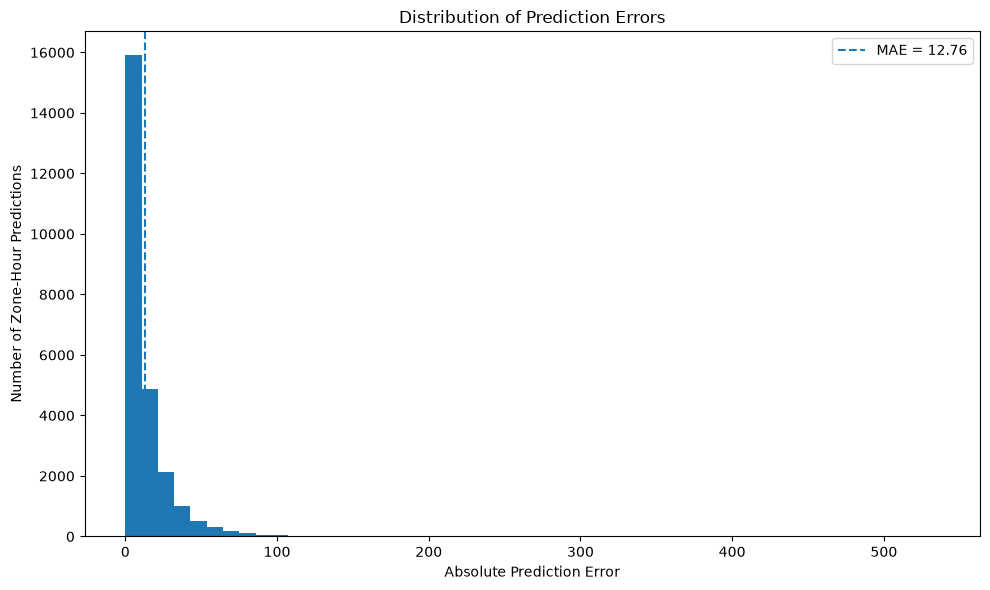

In [35]:
plt.figure(figsize=(10, 6))

plt.hist(
    test_results["absolute_error"],
    bins=50
)

plt.axvline(
    final_mae,
    linestyle="--",
    label=f"MAE = {final_mae:.2f}"
)

plt.xlabel("Absolute Prediction Error")
plt.ylabel("Number of Zone-Hour Predictions")
plt.title("Distribution of Prediction Errors")

plt.legend()
plt.tight_layout()
plt.show()

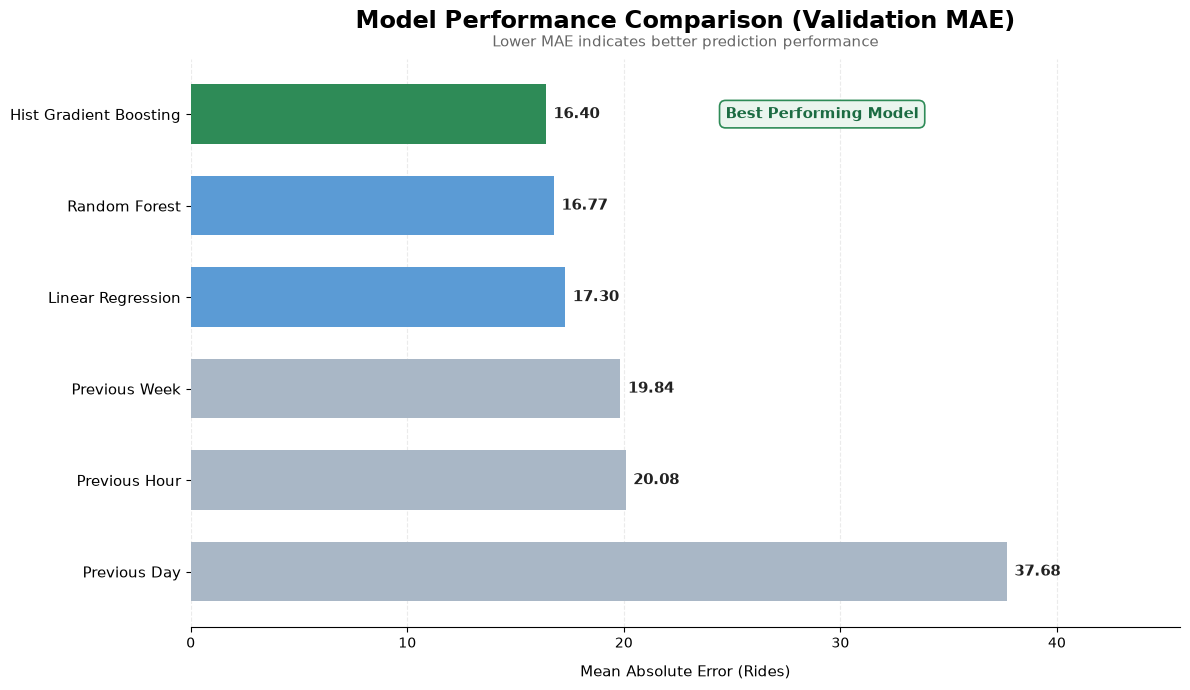

In [40]:
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# MODEL PERFORMANCE DATA
# --------------------------------------------------

model_scores = pd.DataFrame({
    "Model": [
        "Previous Hour",
        "Previous Day",
        "Previous Week",
        "Linear Regression",
        "Random Forest",
        "Hist Gradient Boosting"
    ],
    "MAE": [
        20.081221,
        37.682985,
        19.842153,
        17.296208,
        16.772401,
        16.401461
    ],
    "Type": [
        "Baseline",
        "Baseline",
        "Baseline",
        "Machine Learning",
        "Machine Learning",
        "Machine Learning"
    ]
})


# --------------------------------------------------
# SORT MODELS BY PERFORMANCE
# Lower MAE = Better
# --------------------------------------------------

plot_data = (
    model_scores
    .sort_values("MAE", ascending=True)
    .reset_index(drop=True)
)


# --------------------------------------------------
# CREATE FIGURE
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))


# --------------------------------------------------
# DEFINE COLORS
# --------------------------------------------------

colors = []

for model, model_type in zip(
    plot_data["Model"],
    plot_data["Type"]
):
    if model == "Hist Gradient Boosting":
        # Final selected model
        colors.append("#2E8B57")

    elif model_type == "Machine Learning":
        # Other ML models
        colors.append("#5B9BD5")

    else:
        # Baseline models
        colors.append("#A9B7C6")


# --------------------------------------------------
# CREATE HORIZONTAL BAR CHART
# --------------------------------------------------

bars = ax.barh(
    plot_data["Model"],
    plot_data["MAE"],
    color=colors,
    height=0.65
)

# Put the best model at the top
ax.invert_yaxis()


# --------------------------------------------------
# ADD MAE VALUES
# --------------------------------------------------

for bar, value in zip(
    bars,
    plot_data["MAE"]
):
    ax.text(
        value + 0.35,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#222222"
    )


# --------------------------------------------------
# TITLE
# --------------------------------------------------

ax.set_title(
    "Model Performance Comparison (Validation MAE)",
    fontsize=17,
    fontweight="bold",
    pad=22
)


# --------------------------------------------------
# SUBTITLE
# --------------------------------------------------

ax.text(
    0.5,
    1.015,
    "Lower MAE indicates better prediction performance",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color="#666666"
)


# --------------------------------------------------
# AXIS LABELS
# --------------------------------------------------

ax.set_xlabel(
    "Mean Absolute Error (Rides)",
    fontsize=11,
    labelpad=10
)

ax.set_ylabel("")

ax.tick_params(
    axis="y",
    labelsize=11
)

ax.tick_params(
    axis="x",
    labelsize=10
)


# --------------------------------------------------
# GRID
# --------------------------------------------------

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.25
)

ax.set_axisbelow(True)


# --------------------------------------------------
# CLEAN CHART BORDERS
# --------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


# --------------------------------------------------
# BEST MODEL LABEL
# --------------------------------------------------

best_index = plot_data[
    plot_data["Model"] == "Hist Gradient Boosting"
].index[0]

best_value = plot_data.loc[
    best_index,
    "MAE"
]

ax.text(
    best_value + 8.3,
    best_index,
    "Best Performing Model",
    va="center",
    ha="left",
    fontsize=11,
    fontweight="bold",
    color="#1B6B42",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#EAF5EE",
        edgecolor="#2E8B57",
        linewidth=1.2
    )
)


# --------------------------------------------------
# EXTRA SPACE FOR VALUES AND LABEL
# --------------------------------------------------

ax.set_xlim(
    0,
    plot_data["MAE"].max() + 8
)


# --------------------------------------------------
# FINAL LAYOUT
# --------------------------------------------------

plt.tight_layout()

plt.show()

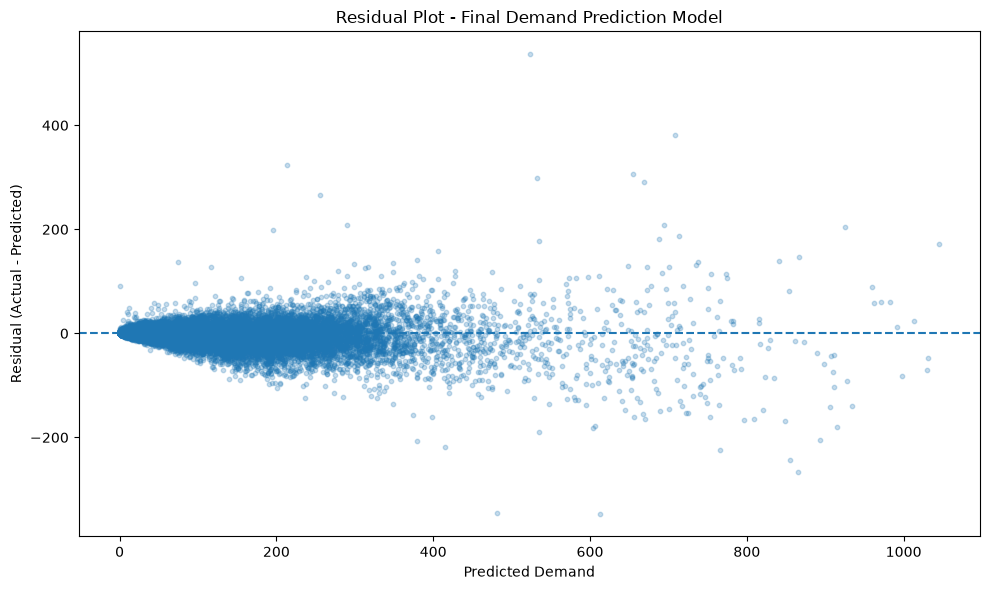

In [41]:
residuals = y_test.to_numpy() - test_pred

plt.figure(figsize=(10, 6))

plt.scatter(
    test_pred,
    residuals,
    alpha=0.25,
    s=10
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Demand")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot - Final Demand Prediction Model")

plt.tight_layout()
plt.show()

Residual Analysis: The residuals are generally distributed around zero, indicating that the model does not show a strong overall prediction bias. However, the spread of residuals increases at higher demand levels, suggesting that prediction uncertainty is greater during high-demand periods. A small number of large residuals are also visible, representing unusually difficult zone-hour demand observations.